# 2×3 Binned Heatmap Matrix

This notebook accepts six pandas DataFrames and plots a 2×3 matrix of binned heatmaps. Each heatmap uses the same x/y variable columns and a shared color scale for easy comparison.

In [63]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

sns.set_theme(style="white")

In [ ]:
def compute_binned_counts(df, x_col, y_col, x_bins, y_bins, x_range, y_range, y_convert=None):
    x = df[x_col].to_numpy(dtype=float)
    y = df[y_col].to_numpy(dtype=float)
    if y_convert == "kelvin_to_celsius":
        y = y - 273.15
    heatmap, xedges, yedges = np.histogram2d(
        x, y, bins=[x_bins, y_bins], range=[x_range, y_range]
    )
    return heatmap.T, xedges, yedges

def plot_heatmap_grid(
    dfs,
    x_col,
    y_col,
    labels=None,
    bins=40,
    figsize=(18, 10),
    cmap="mako",
    x_range=None,
    y_range=None,
    y_convert=None,
):
    if len(dfs) != 6:
        raise ValueError(
            "plot_heatmap_grid requires exactly 6 DataFrames (2 rows × 3 columns)."
        )

    if labels is None:
        labels = [f"DataFrame {i + 1}" for i in range(6)]
    elif len(labels) != 6:
        raise ValueError("labels must contain exactly 6 strings.")

    # Shared axis ranges for comparable heatmaps
    x_values = np.concatenate([df[x_col].to_numpy(dtype=float) for df in dfs])
    y_values = np.concatenate([df[y_col].to_numpy(dtype=float) for df in dfs])
    if y_convert == "kelvin_to_celsius":
        y_values = y_values - 273.15

    if x_range is None:
        x_range = (np.nanmin(x_values), np.nanmax(x_values))
    if y_range is None:
        y_range = (5, 45) if y_convert == "kelvin_to_celsius" else (np.nanmin(y_values), np.nanmax(y_values))

    heatmaps = [
        compute_binned_counts(
            df,
            x_col,
            y_col,
            bins,
            bins,
            x_range,
            y_range,
            y_convert=y_convert,
        )
        for df in dfs
    ]

    # Use a fixed colorbar maximum to keep the legend capped at 50
    vmax = 50

    xlabel = x_col
    ylabel = f"{y_col} (°C)" if y_convert == "kelvin_to_celsius" else y_col

    fig, axes = plt.subplots(2, 3, figsize=figsize, constrained_layout=True)
    for idx, (heatmap, xedges, yedges) in enumerate(heatmaps):
        ax = axes.flat[idx]
        sns.heatmap(
            heatmap,
            ax=ax,
            cmap=cmap,
            vmin=0,
            vmax=vmax,
            cbar=(idx == 5),
            cbar_kws={
                "label": "Count"
            },
            xticklabels=False,
            yticklabels=False,
            linewidths=0,
            linecolor="none",
        )
        ax.set_title(labels[idx])
        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)
        ax.invert_yaxis()

    fig.suptitle(
        f"",
        fontsize=16,
        y=1.02,
    )

    for ax in axes.flat:
        ax.collections[0].set_rasterized(True)

    plt.savefig("heatmap_six.pdf")

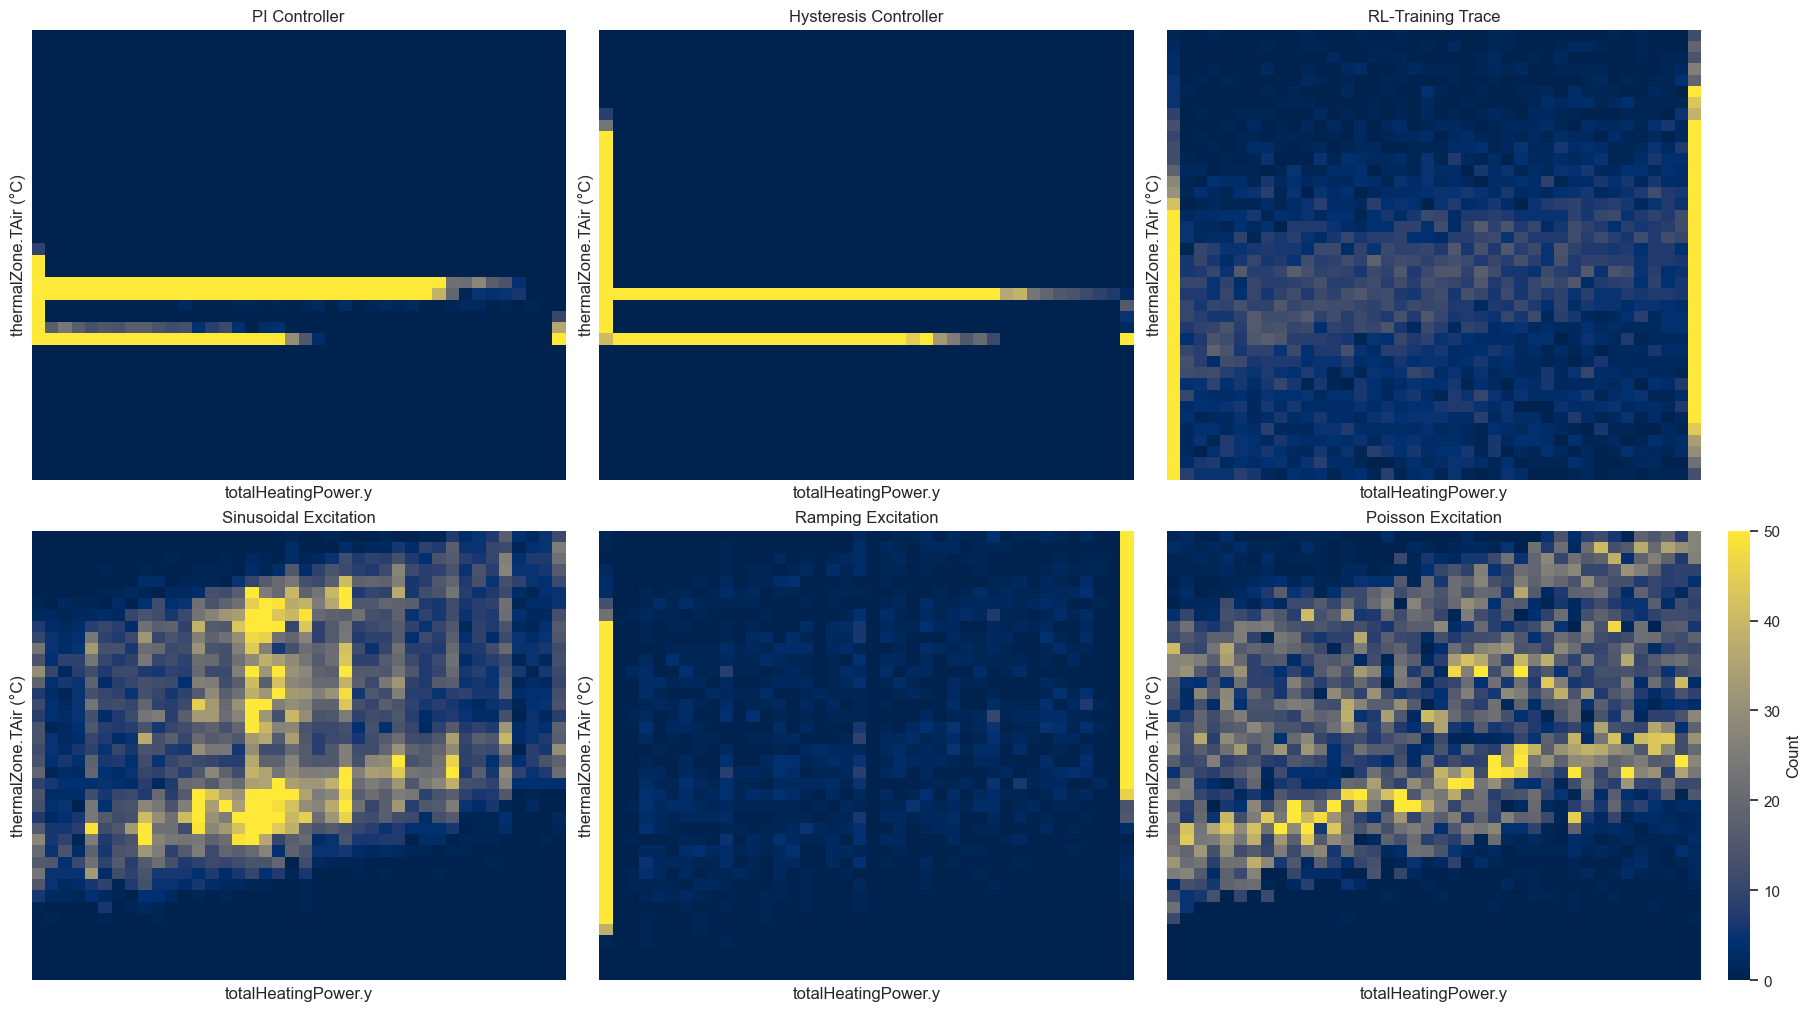

In [95]:
# RL trace
df_rl = pd.read_csv("om_fmu_trace_rl.csv")[["obs_thermalZone_TAir","obs_totalHeatingPower_y"]]
renames = {
    "obs_thermalZone_TAir": "thermalZone.TAir",
    "obs_totalHeatingPower_y": "totalHeatingPower.y"
}
df_rl["thermalZone.TAir"] = df_rl["obs_thermalZone_TAir"]
df_rl["totalHeatingPower.y"] = df_rl["obs_totalHeatingPower_y"]
df_rl = df_rl[["thermalZone.TAir", "totalHeatingPower.y"]]

df_pi = pd.read_csv("pi_ctr.csv")
df_pi["totalHeatingPower.y"] = df_pi["totalHeatingPower.y"] / max(df_pi["totalHeatingPower.y"]) * 3700

# HYsteresis Dataframe
df_hys = pd.read_csv("hysteresis_trace.csv")

# Sinusoidal Dataframe
df_sin = pd.read_csv("sinosoidal_trace.csv")
df_sin["totalHeatingPower.y"] = df_sin["totalHeatingPower.y"] / max(df_sin["totalHeatingPower.y"]) * 3700

# Ramp Dataframe
df_ramp = pd.read_csv("ramp_trace.csv")
df_ramp["totalHeatingPower.y"] = df_ramp["totalHeatingPower.y"] / max(df_ramp["totalHeatingPower.y"]) * 3700

# Poisson Exccitation
df_pois = pd.read_csv("poisson_trace.csv")
df_pois["totalHeatingPower.y"] = df_pois["totalHeatingPower.y"] / max(df_pois["totalHeatingPower.y"]) * 3700



dfs = [
    df_pi,
    df_hys,
    df_rl,
    df_sin,
    df_ramp,
    df_pois
]
labels = [
    "PI Controller",
    "Hysteresis Controller",
    "RL-Training Trace",
    "Sinusoidal Excitation",
    "Ramping Excitation",
    "Poisson Excitation",
]

plot_heatmap_grid(
    dfs=dfs,
    x_col="totalHeatingPower.y",
    y_col="thermalZone.TAir",
    labels=labels,
    bins=40,
    cmap="cividis",
    y_convert="kelvin_to_celsius",
)